# Bus Route Analysis with Reusable Functions

This notebook demonstrates how to refactor the bus route analysis code into reusable functions that can be applied to different data tables.

## 1. Setup Environment and Imports

In [1]:
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Add parent directory to path if needed
sys.path.append(str(pathlib.Path.cwd()))

## 2. Define Reusable Processing Functions

All functions are self-contained and can be used on any table with compatible columns.

In [14]:
def load_and_clean_data(file_path):
    """Load CSV file and clean data by removing NaN values and duplicates."""
    df = pd.read_csv(file_path)
    
    # Remove rows with NaN in route_name
    df = df.dropna(subset=['route_name'])
    
    # Find and remove duplicate rows
    duplicates = df[df.duplicated()]
    print(f"Number of duplicate rows: {len(duplicates)}")
    df = df.drop_duplicates()
    
    return df


def sort_and_analyze_data(df):
    """Sort dataframe and analyze route blocks."""
    df_sorted = df.sort_values(['route_id', 'month', 'day_of_week', 'scheduled_departure_time', 'stop_sequence'])
    
    route_blocks = df_sorted.groupby(['route_id', 'month', 'day_of_week', 'scheduled_departure_time'])
    block_size = route_blocks.size().reset_index(name='n_stops')
    
    return df_sorted, route_blocks, block_size


def extract_route_sequences(route_blocks):
    """Extract route sequences from grouped data."""
    def get_route_sequence(group):
        return group.sort_values('stop_sequence')['stop_code'].tolist()
    
    route_sequences = route_blocks.apply(get_route_sequence).reset_index()
    route_sequences = route_sequences.rename(columns={0: 'route_sequence'})
    
    # Convert to string format
    route_sequences['route_sequence_str'] = route_sequences['route_sequence'].apply(
        lambda x: '-'.join(map(str, x))
    )
    
    # Count occurrences - properly handle value_counts() return
    route_counts = route_sequences['route_sequence_str'].value_counts().reset_index(name='count')
    route_counts = route_counts.rename(columns={'index': 'route_sequence_str'})
    
    # Add number of stops column
    route_counts['n_stops'] = route_counts['route_sequence_str'].apply(lambda x: len(x.split('-')))
    
    return route_sequences, route_counts


def get_most_common_route(route_counts):
    """Get the most common route sequence."""
    most_common_route_str = route_counts.iloc[0]['route_sequence_str']
    most_common_route = most_common_route_str.split('-')
    
    return most_common_route_str, most_common_route


def filter_and_classify_routes(route_counts, most_common_route_str):
    """Filter routes and classify by number of stops."""
    # Remove the most common route
    other_routes = route_counts[route_counts['route_sequence_str'] != most_common_route_str]
    
    # Sort by number of stops and count
    other_routes_sorted = other_routes.sort_values(by=['n_stops', 'count'])
    
    # Get distribution of stops
    stops_distribution = other_routes_sorted.groupby('n_stops').size().reset_index(name='n_routes')
    stops_distribution = stops_distribution.sort_values(by='n_stops')
    
    return other_routes_sorted, stops_distribution


def load_stops_mapping(stops_file):
    """Load stops information and create mapping from code to name."""
    stops_df = pd.read_csv(stops_file)
    stop_code_to_name = dict(zip(stops_df['stop_code'], stops_df['stop_name']))
    return stop_code_to_name


def get_stop_names(stop_codes, stop_code_to_name):
    """Convert stop codes string to list of stop names."""
    codes = stop_codes.split('-')
    names = [stop_code_to_name.get(int(code), f"Unknown({code})") for code in codes]
    return names


def filter_by_stop_count(other_routes_sorted, min_stops=10, max_stops=50):
    """Filter routes by number of stops."""
    filtered_routes = other_routes_sorted[
        (other_routes_sorted['n_stops'] >= min_stops) & 
        (other_routes_sorted['n_stops'] <= max_stops)
    ]
    print(f"Number of routes after filtering ({min_stops}-{max_stops} stops): {len(filtered_routes)}")
    return filtered_routes


def create_heatmap_data(subset_routes, reference_stations, stop_code_to_name):
    """Create heatmap data showing which reference stations appear in each route."""
    heatmap_data = []
    labels_y = []
    
    for idx, row in subset_routes.iterrows():
        # Extract stops of current route
        current_route_stops = set(get_stop_names(row['route_sequence_str'], stop_code_to_name))
        
        # Build vector: 1 if stop from reference is in current route, 0 otherwise
        vector = [1 if stop in current_route_stops else 0 for stop in reference_stations]
        
        heatmap_data.append(vector)
        labels_y.append(f"Route {idx}")
    
    heatmap_data = np.array(heatmap_data)
    return heatmap_data, labels_y


def plot_routes_heatmap(heatmap_data, reference_stations, labels_y, bin_label):
    """Plot heatmap showing route coverage."""
    station_labels_rtl = reference_stations
    station_labels_rtl = [label[::-1] if label != "" else "" for label in station_labels_rtl]
    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, annot=False, cbar=False, cmap='YlGnBu',
                xticklabels=station_labels_rtl, yticklabels=labels_y,
                linecolor='black', linewidths=0.5)
    
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Heatmap for routes with {bin_label} stops (0=absent, 1=present)")
    plt.ylabel("Route Index")
    plt.xlabel("Stations (in most common route order)")
    plt.tight_layout()
    plt.show()


def plot_rare_routes(other_routes_sorted):
    """Plot scatter plot of rare routes (stops vs occurrences)."""
    plt.figure(figsize=(10, 6))
    plt.scatter(other_routes_sorted['n_stops'], other_routes_sorted['count'], alpha=0.7)
    plt.xlabel('Number of stops in route')
    plt.ylabel('Number of occurrences')
    plt.title('Rare route sequences: number of stops vs occurrences')
    plt.grid(True)
    plt.show()

## 3. Apply Functions to a Table

Change the file paths to any CSV file with the required columns. The functions will work on any compatible table.

ANALYZING TABLE: renamed_ride_data_15.csv

1. Loading and cleaning data...
Number of duplicate rows: 11412
Data shape after cleaning: (46645, 13)

2. Sorting and analyzing routes...

3. Extracting route sequences...
Total unique route sequences: 88

DEBUGGING extract_route_sequences output:
Type of route_counts: <class 'pandas.DataFrame'>
Columns: ['route_sequence_str', 'count', 'n_stops']
First row:
                                  route_sequence_str  count  n_stops
0  3300-3301-5987-5988-9921-2540-1255-1028-1856-1...    863       48
Data:
route_sequence_str      str
count                 int64
n_stops               int64
dtype: object

4. Finding most common route...
Most common route has 48 stops

5. Filtering and classifying routes...

6. Plotting rare routes distribution...


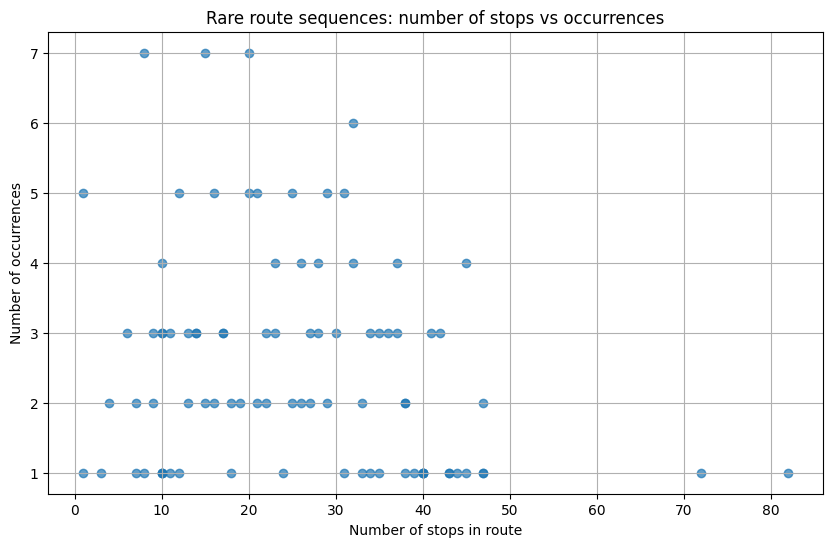

In [15]:
# Configure paths - change these to analyze different tables
ride_data_path = r"C:\Users\User\Documents\שנה ג\data_science\data-science\govData\renamed_ride_data_15.csv"
stops_data_path = r"C:\Users\User\Documents\שנה ג\data_science\data-science\govData\jerusalem_stops.csv"

print("=" * 60)
print("ANALYZING TABLE:", ride_data_path.split("\\")[-1])
print("=" * 60)

# Step 1: Load and clean data
print("\n1. Loading and cleaning data...")
df = load_and_clean_data(ride_data_path)
print(f"Data shape after cleaning: {df.shape}")

# Step 2: Sort and analyze
print("\n2. Sorting and analyzing routes...")
df_sorted, route_blocks, block_size = sort_and_analyze_data(df)

# Step 3: Extract sequences

print("\n3. Extracting route sequences...")
route_sequences, route_counts = extract_route_sequences(route_blocks)
print(f"Total unique route sequences: {route_counts.shape[0]}")
# After extract_route_sequences, add debugging:
print("\nDEBUGGING extract_route_sequences output:")
print(f"Type of route_counts: {type(route_counts)}")
print(f"Columns: {route_counts.columns.tolist() if hasattr(route_counts, 'columns') else 'N/A'}")
print(f"First row:\n{route_counts.head(1)}")
print(f"Data:\n{route_counts.dtypes}")

# Step 4: Get most common route
print("\n4. Finding most common route...")
most_common_route_str, most_common_route = get_most_common_route(route_counts)
print(f"Most common route has {route_counts.iloc[0]['n_stops']} stops")

# Step 5: Filter and classify
print("\n5. Filtering and classifying routes...")
other_routes_sorted, stops_distribution = filter_and_classify_routes(route_counts, most_common_route_str)

# Step 6: Plot rare routes
print("\n6. Plotting rare routes distribution...")
plot_rare_routes(other_routes_sorted)


7. Filtering routes by stop count...
Number of routes after filtering (10-50 stops): 74

8. Loading stops mapping...

9. Preparing reference stations from most common route...
Reference stations: 48 stops

10. Creating heatmaps for routes by stop count...

Processing 10-20 routes (19 routes)...


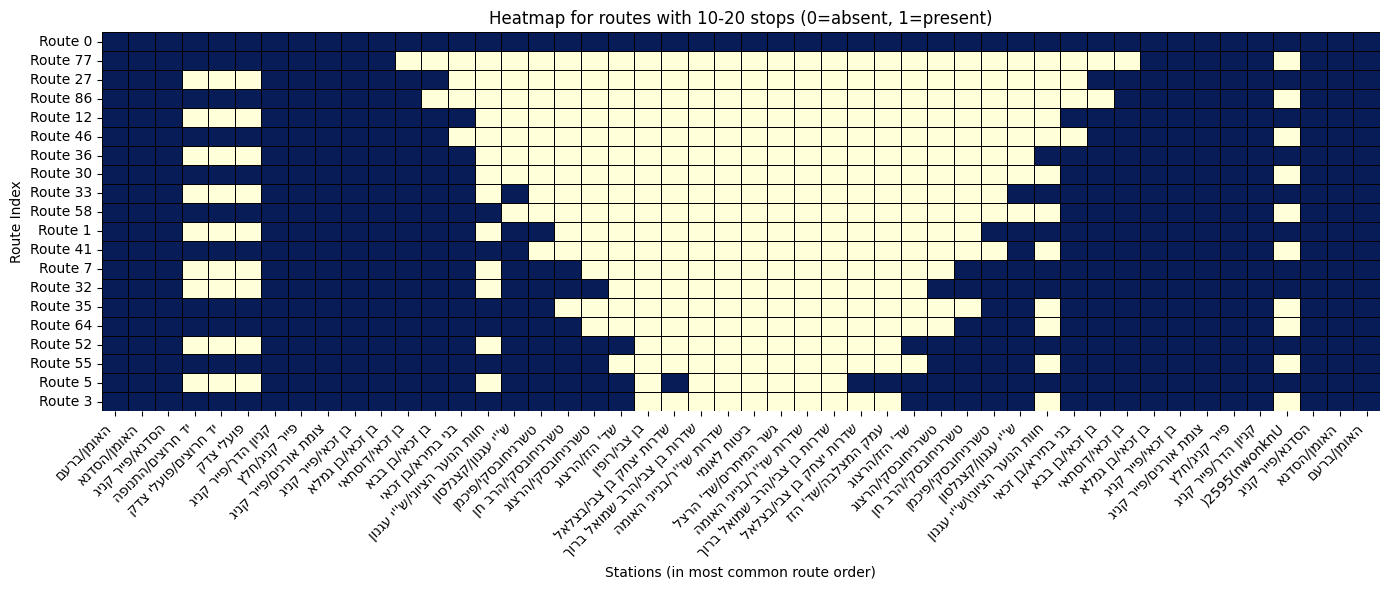


Processing 20-30 routes (18 routes)...


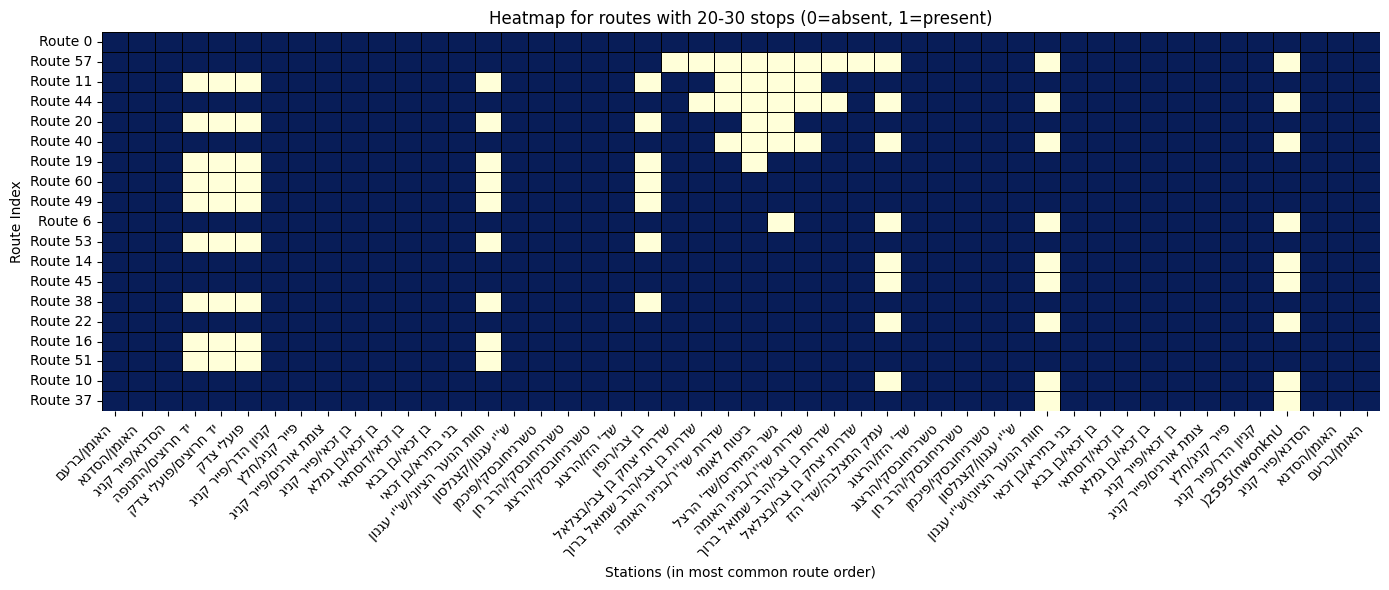


Processing 30-40 routes (21 routes)...


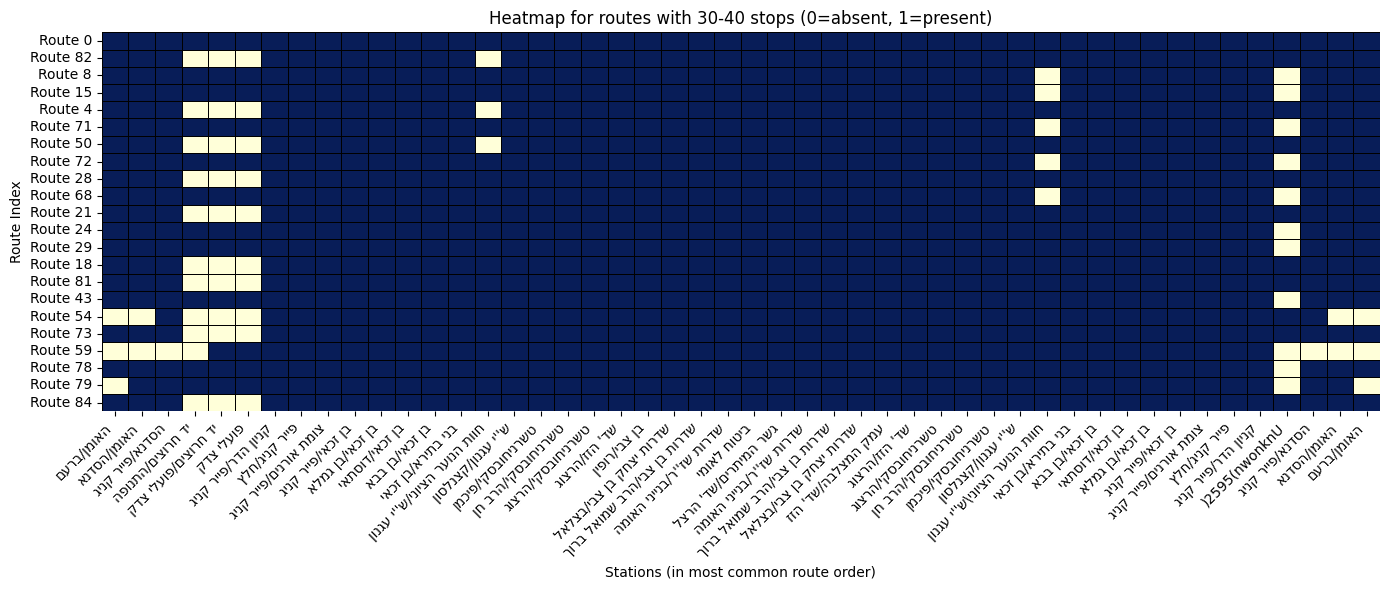


Processing 40-50 routes (10 routes)...


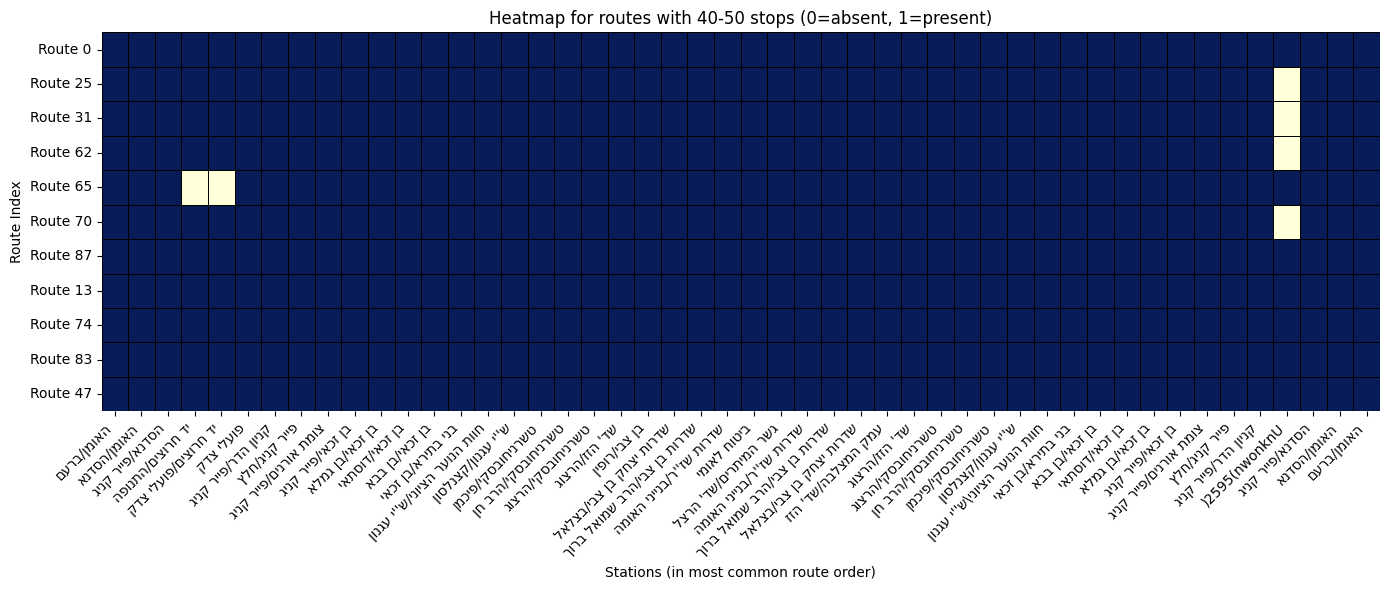


Analysis complete!


In [16]:
# Step 7: Filter by stop count
print("\n7. Filtering routes by stop count...")
filtered_routes = filter_by_stop_count(other_routes_sorted, min_stops=10, max_stops=50)

# Step 8: Load stops mapping
print("\n8. Loading stops mapping...")
stop_code_to_name = load_stops_mapping(stops_data_path)

# Step 9: Prepare reference stations
print("\n9. Preparing reference stations from most common route...")
reference_stations = get_stop_names(most_common_route_str, stop_code_to_name)
print(f"Reference stations: {len(reference_stations)} stops")

# Step 10: Create heatmaps for different stop count ranges
print("\n10. Creating heatmaps for routes by stop count...")
bins = [10, 20, 30, 40, 50]
bin_labels = ["10-20", "20-30", "30-40", "40-50"]

most_common_df = route_counts[route_counts['route_sequence_str'] == most_common_route_str]

for i in range(len(bins) - 1):
    low = bins[i]
    high = bins[i + 1]
    
    # Filter routes in current range
    subset = filtered_routes[(filtered_routes['n_stops'] > low) & (filtered_routes['n_stops'] <= high)]
    if subset.empty:
        print(f"No routes found in {bin_labels[i]} range")
        continue
    
    print(f"\nProcessing {bin_labels[i]} routes ({len(subset)} routes)...")
    
    # Concat with most common route
    subset_routes = pd.concat([most_common_df, subset])
    
    # Create heatmap data
    heatmap_data, labels_y = create_heatmap_data(subset_routes, reference_stations, stop_code_to_name)
    
    # Plot heatmap
    plot_routes_heatmap(heatmap_data, reference_stations, labels_y, bin_labels[i])

print("\nAnalysis complete!")

## 4. Validate Results on Multiple Tables

You can easily run the same analysis on different tables by changing the file paths below.


Found 5 renamed data files to test

ANALYZING: renamed_ride_data_15.csv
Number of duplicate rows: 11412

✓ Unique routes: 88
✓ Most common route: 48 stops, 863 occurrences
Number of routes after filtering (10-50 stops): 74


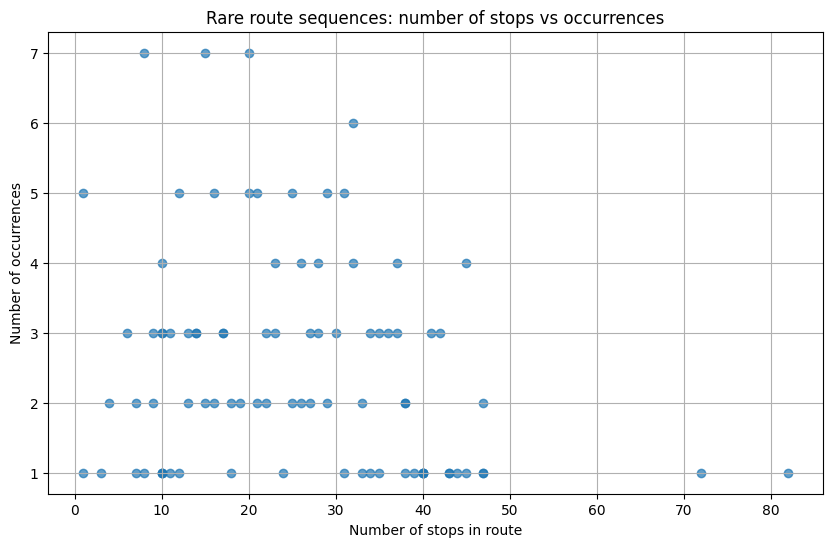


Creating heatmaps for filtered routes...

Processing 10-20 routes (19 routes)...


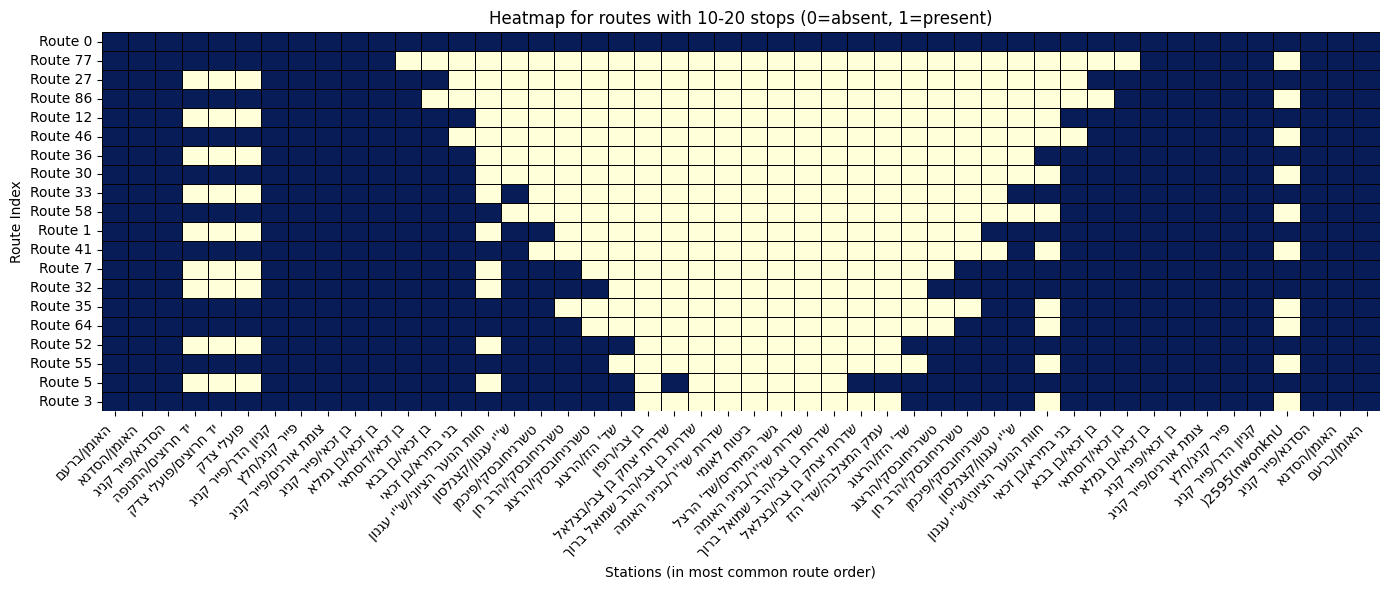


Processing 20-30 routes (18 routes)...


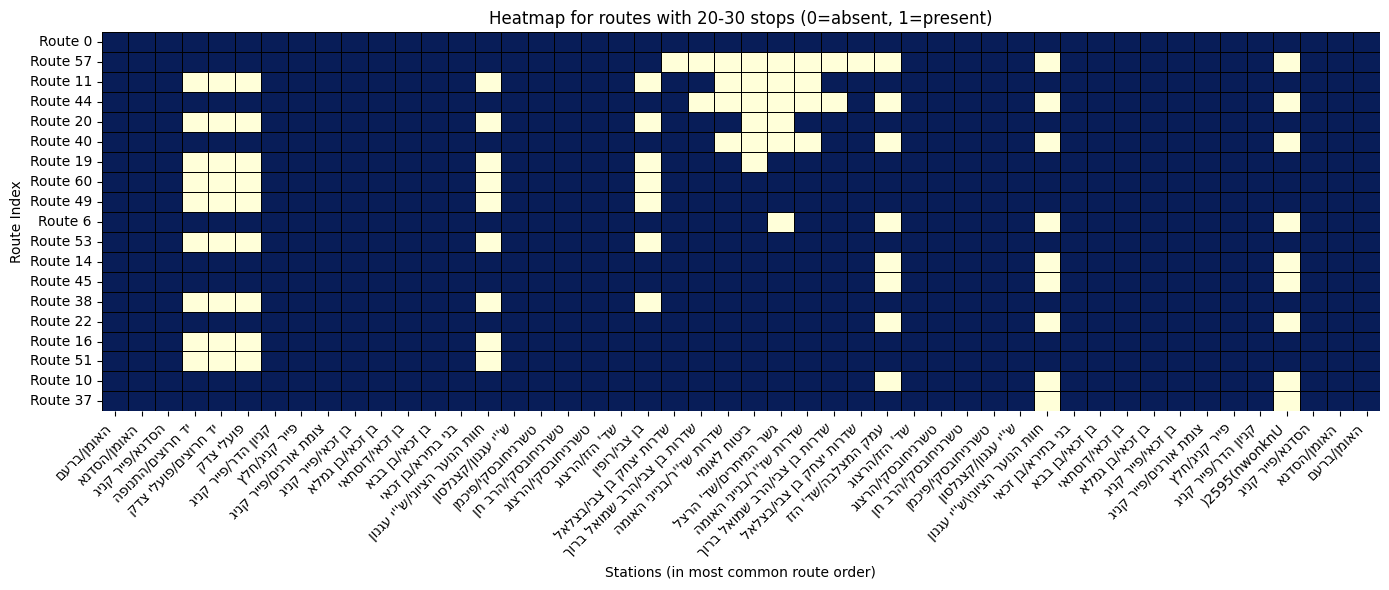


Processing 30-40 routes (21 routes)...


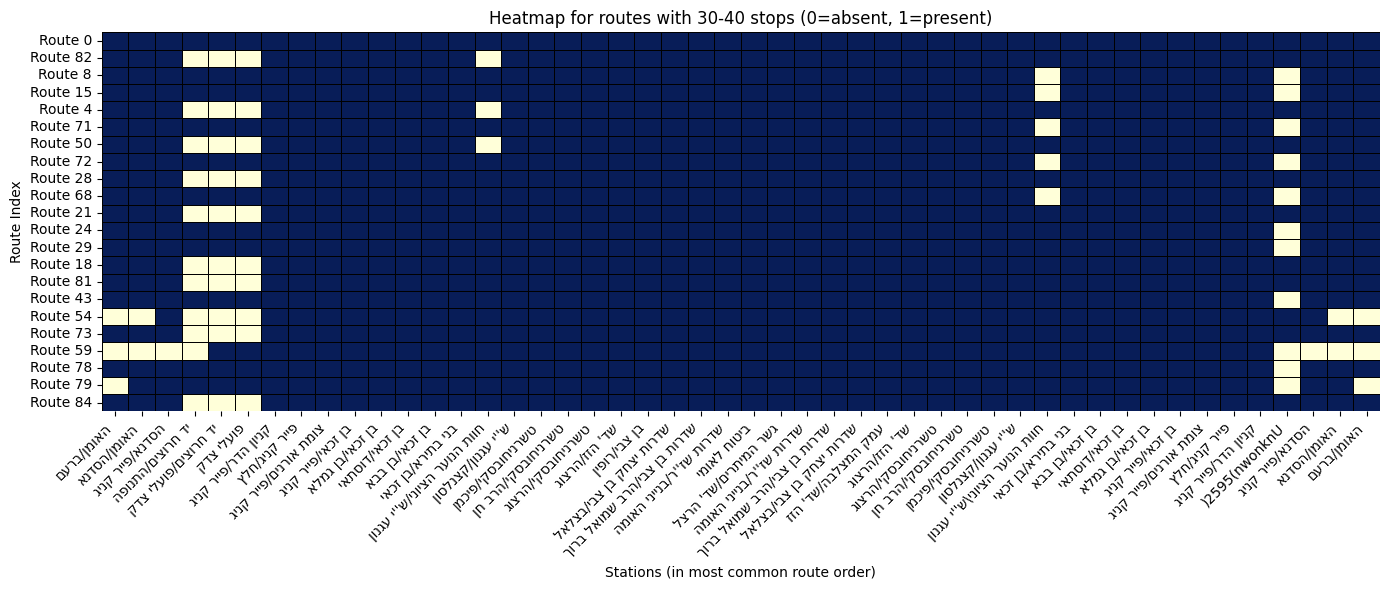


Processing 40-50 routes (10 routes)...


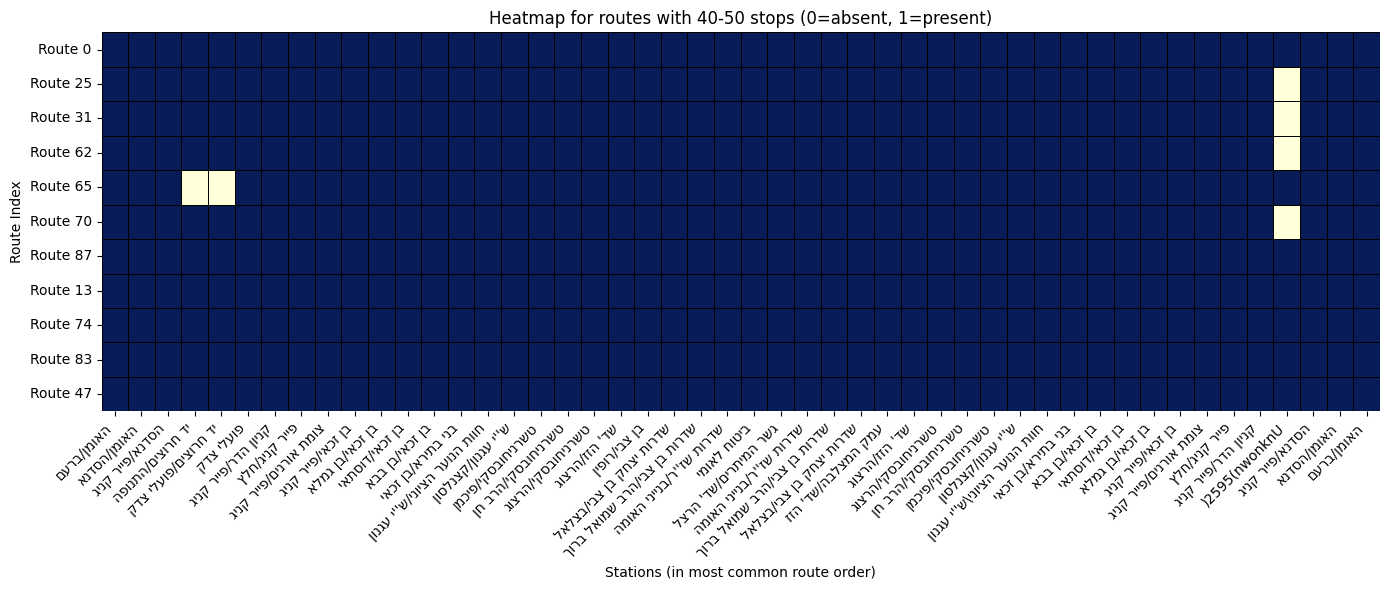




ANALYZING: renamed_ride_data_17.csv
Number of duplicate rows: 6084

✓ Unique routes: 112
✓ Most common route: 47 stops, 287 occurrences
Number of routes after filtering (10-50 stops): 68


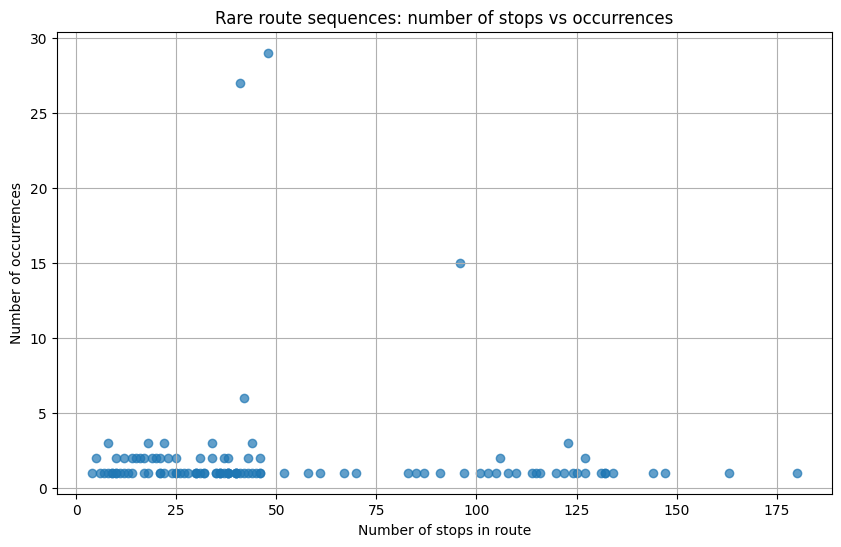


Creating heatmaps for filtered routes...

Processing 10-20 routes (14 routes)...


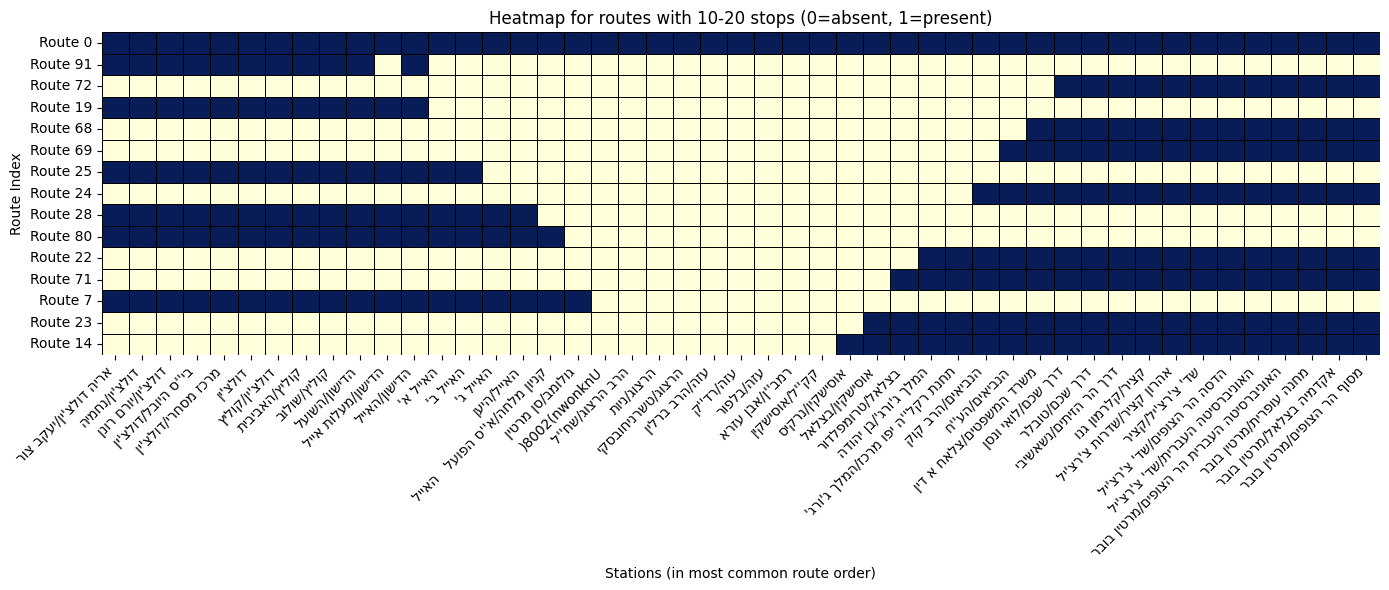


Processing 20-30 routes (16 routes)...


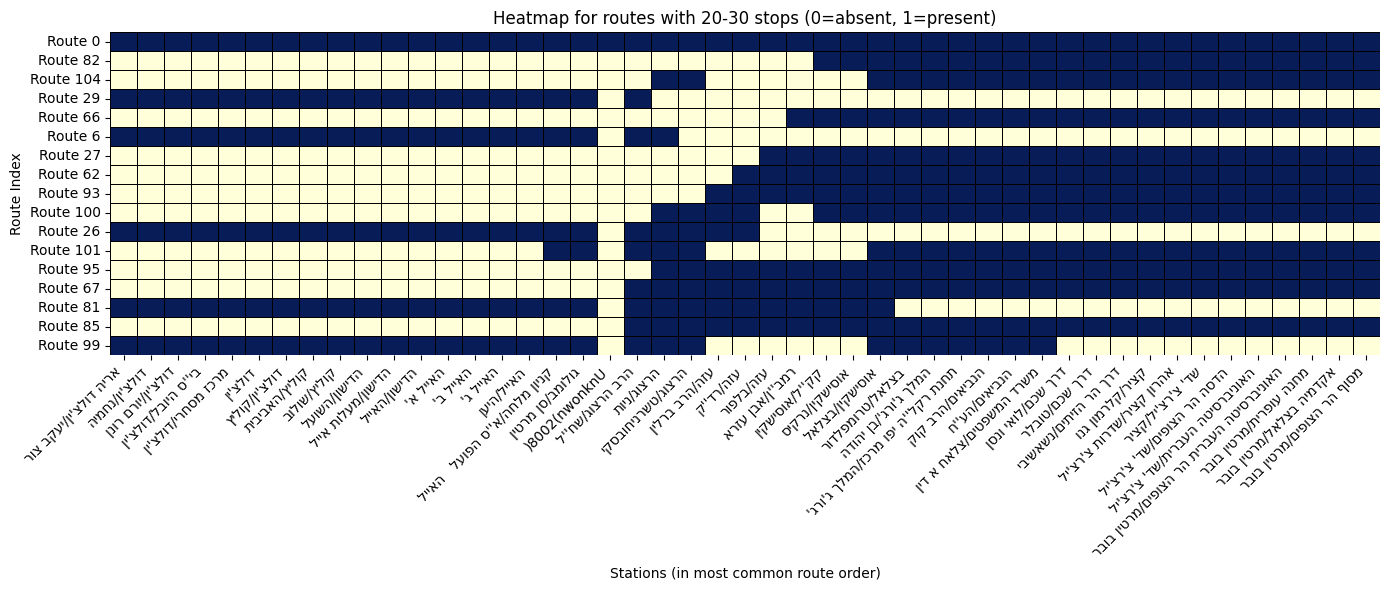


Processing 30-40 routes (22 routes)...


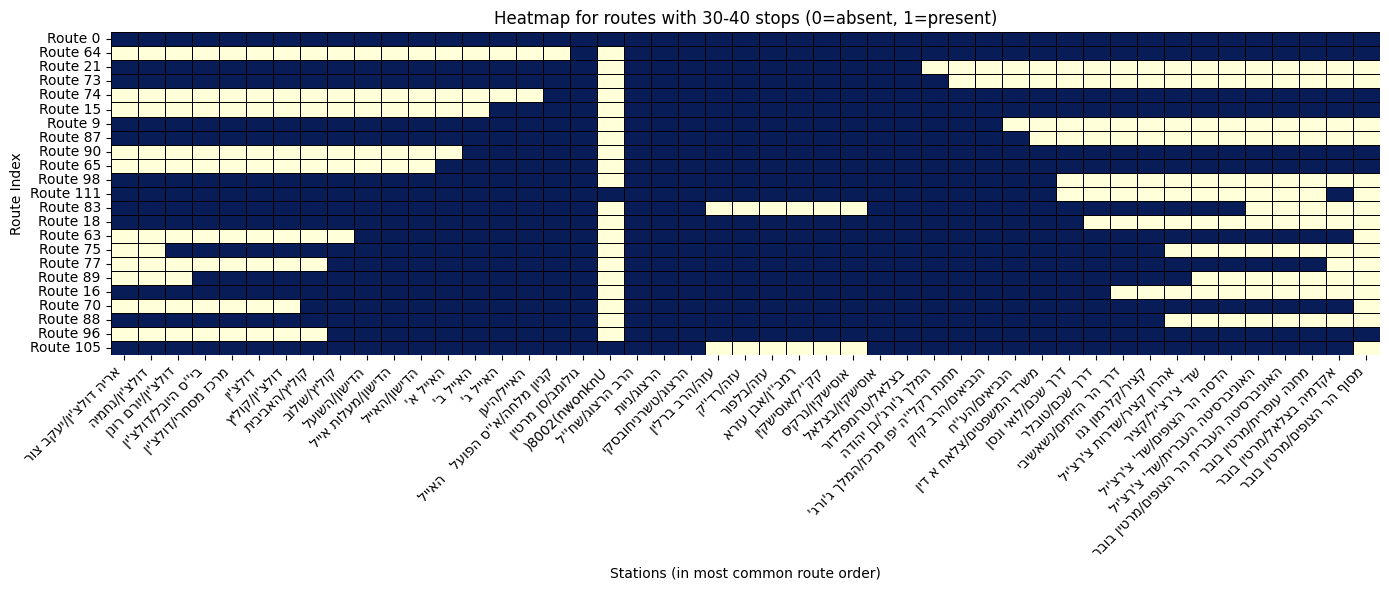


Processing 40-50 routes (13 routes)...


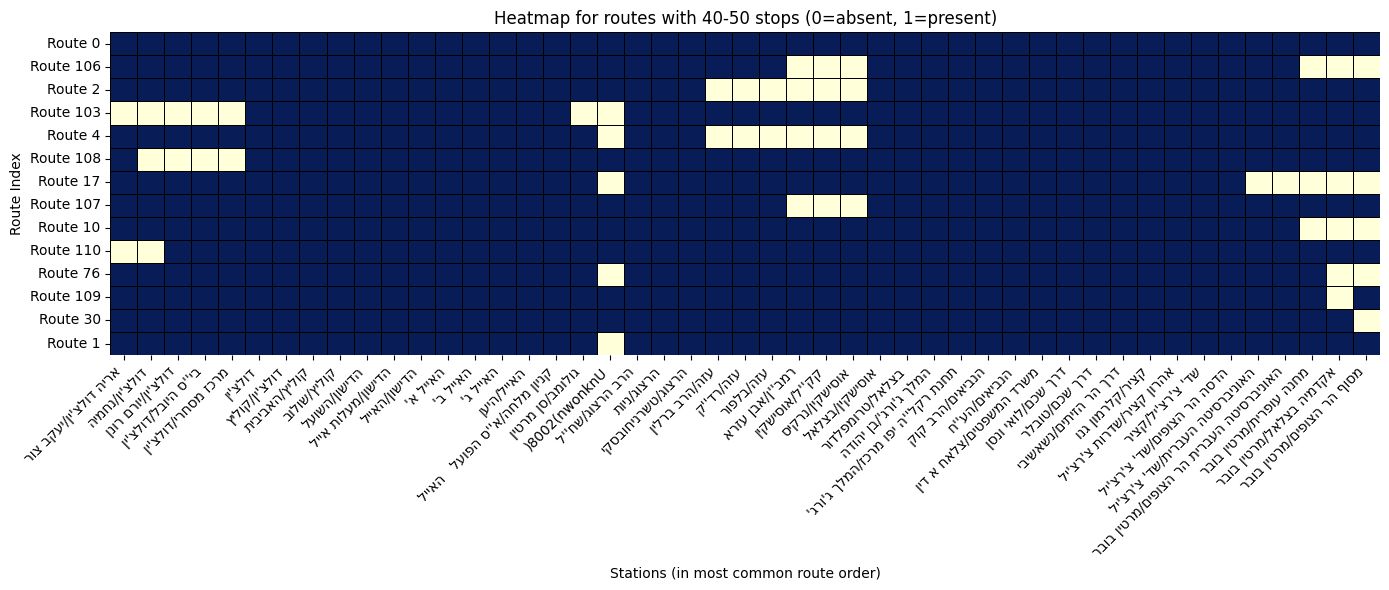




ANALYZING: renamed_ride_data_19.csv
Number of duplicate rows: 8

✓ Unique routes: 34
✓ Most common route: 42 stops, 724 occurrences
Number of routes after filtering (10-50 stops): 20


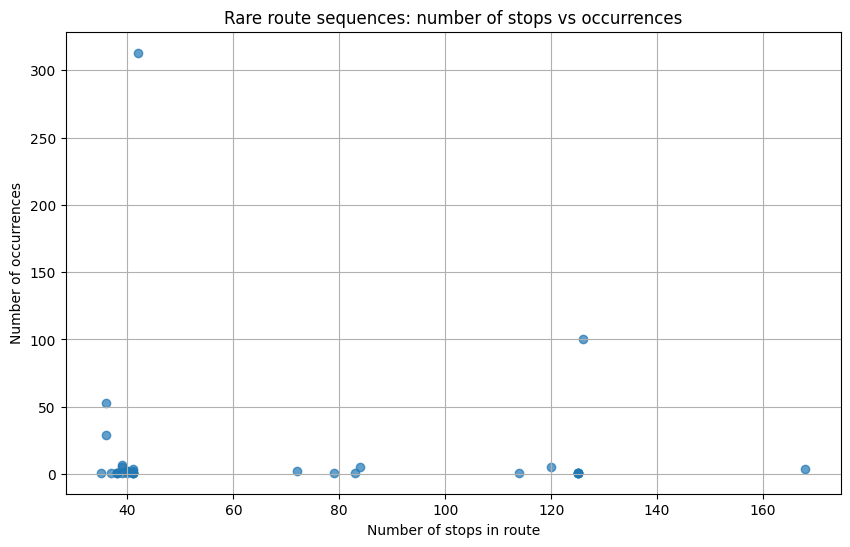


Creating heatmaps for filtered routes...
No routes found in 10-20 range
No routes found in 20-30 range

Processing 30-40 routes (13 routes)...


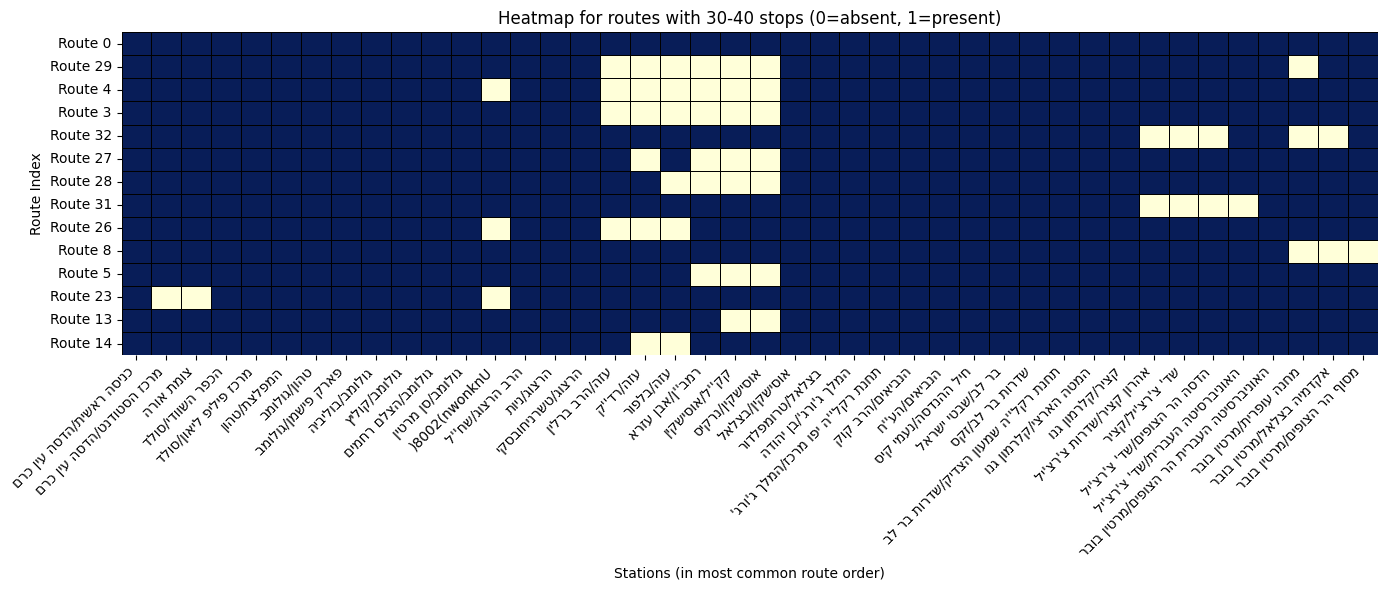


Processing 40-50 routes (7 routes)...


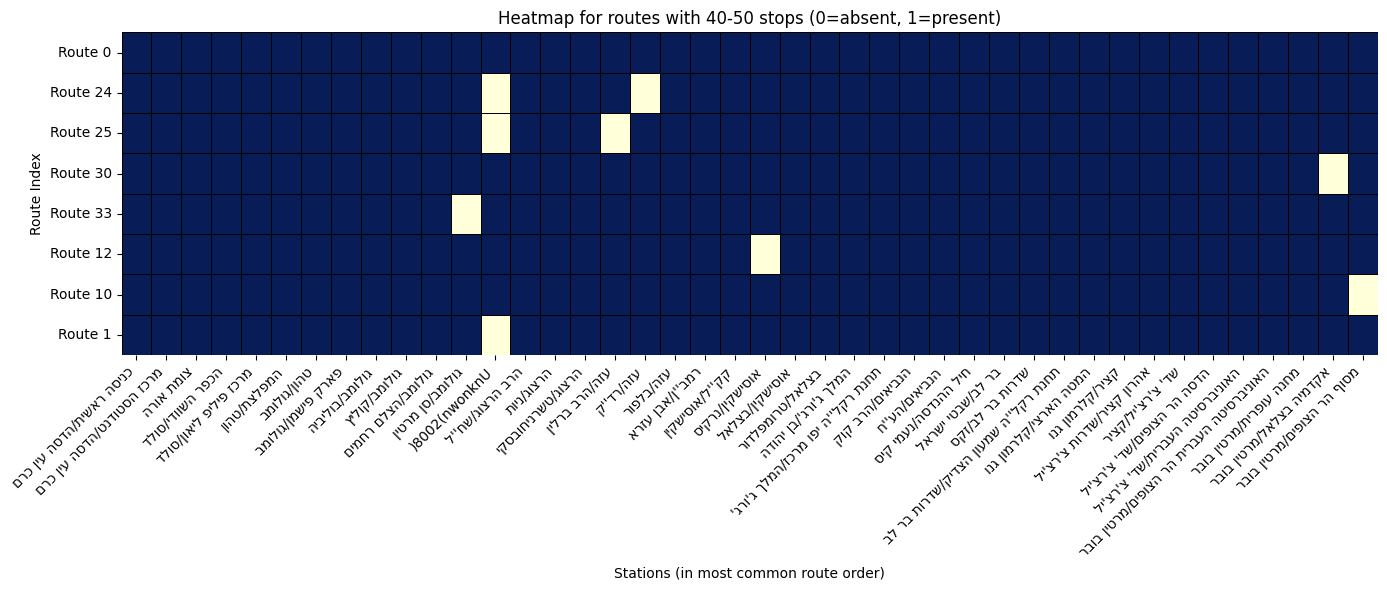




ANALYZING: renamed_ride_data_22.csv
Number of duplicate rows: 5738

✓ Unique routes: 112
✓ Most common route: 55 stops, 876 occurrences
Number of routes after filtering (10-50 stops): 37


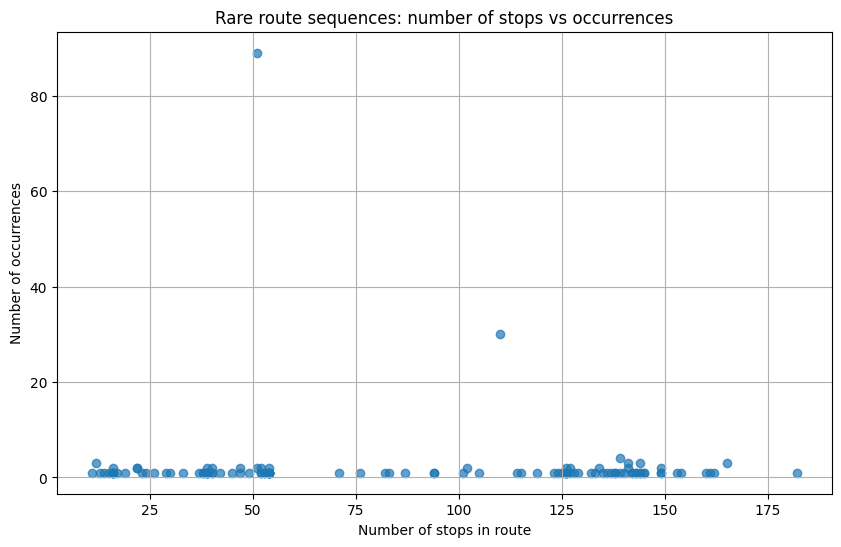


Creating heatmaps for filtered routes...

Processing 10-20 routes (12 routes)...


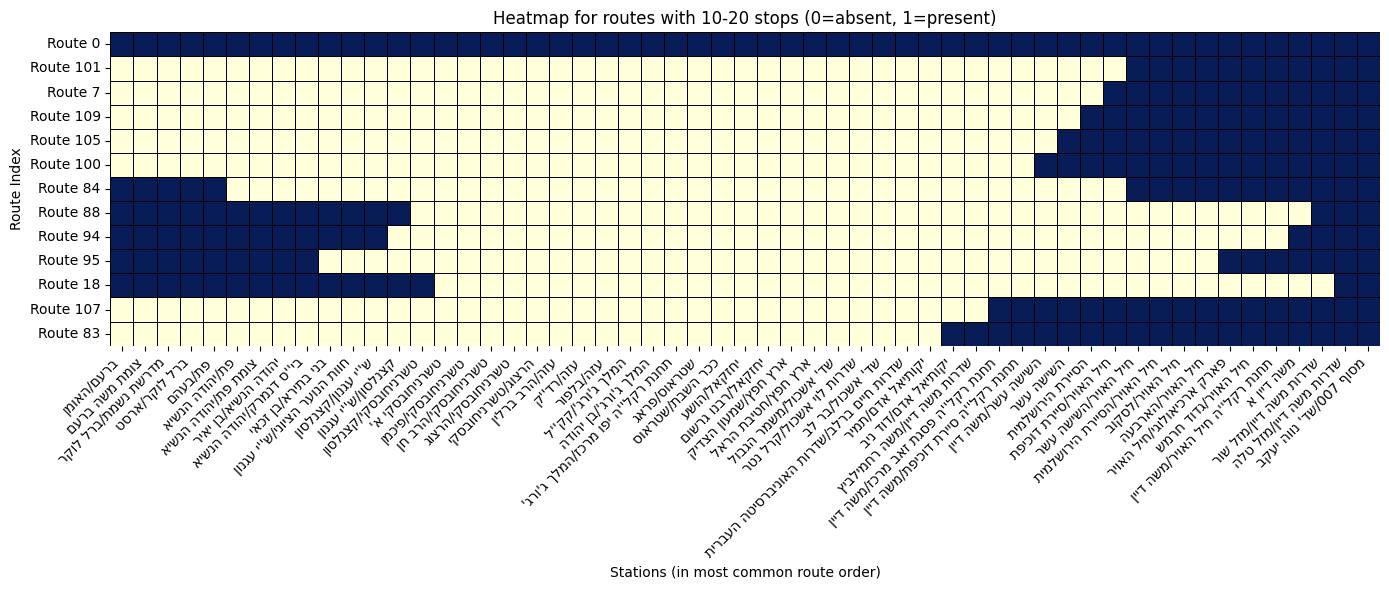


Processing 20-30 routes (7 routes)...


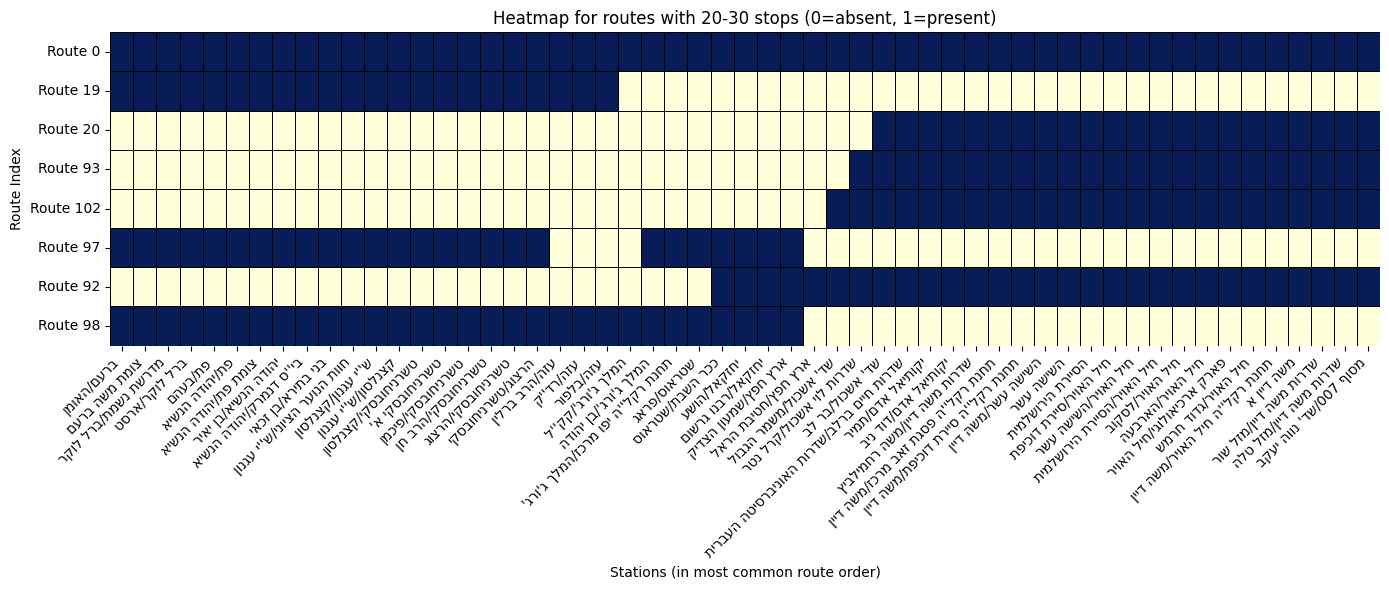


Processing 30-40 routes (13 routes)...


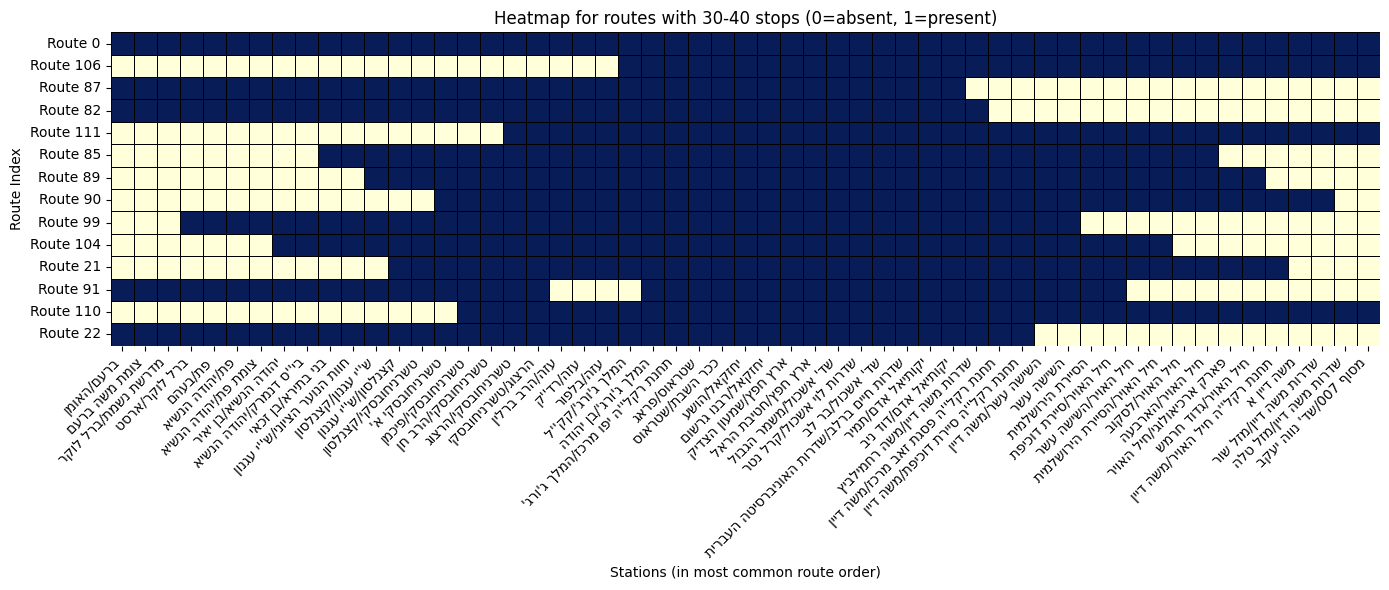


Processing 40-50 routes (5 routes)...


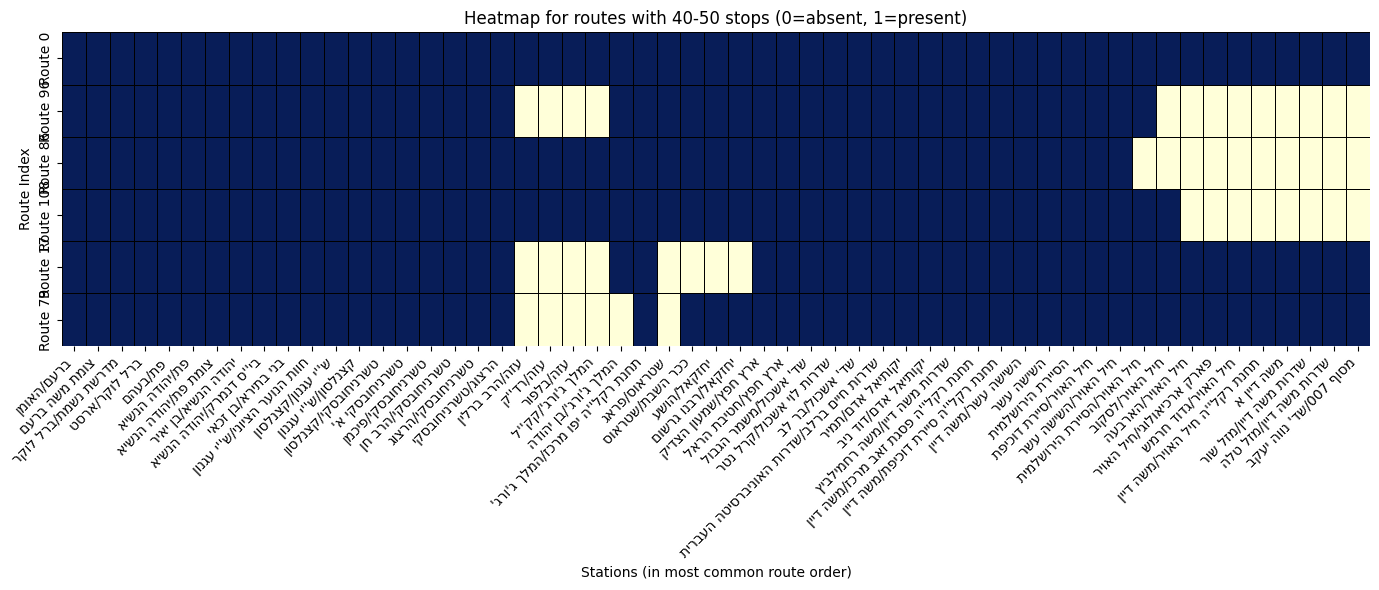

In [17]:
# Function to run complete analysis on any table
def run_full_analysis(ride_data_path, stops_data_path, min_stops=10, max_stops=50):
    """
    Run complete analysis pipeline on a table.
    
    Parameters:
    - ride_data_path: path to ride data CSV
    - stops_data_path: path to stops CSV
    - min_stops: minimum number of stops to filter
    - max_stops: maximum number of stops to filter
    """
    print("\n" + "=" * 70)
    print("ANALYZING:", ride_data_path.split("\\")[-1])
    print("=" * 70)
    
    try:
        df = load_and_clean_data(ride_data_path)
        df_sorted, route_blocks, block_size = sort_and_analyze_data(df)
        route_sequences, route_counts = extract_route_sequences(route_blocks)
        most_common_route_str, most_common_route = get_most_common_route(route_counts)
        other_routes_sorted, stops_distribution = filter_and_classify_routes(route_counts, most_common_route_str)
        
        print(f"\n✓ Unique routes: {route_counts.shape[0]}")
        print(f"✓ Most common route: {route_counts.iloc[0]['n_stops']} stops, {route_counts.iloc[0]['count']} occurrences")
        
        filtered_routes = filter_by_stop_count(other_routes_sorted, min_stops=min_stops, max_stops=max_stops)
        stop_code_to_name = load_stops_mapping(stops_data_path)
        reference_stations = get_stop_names(most_common_route_str, stop_code_to_name)
        
        plot_rare_routes(other_routes_sorted)
        
        print("\nCreating heatmaps for filtered routes...")
        bins = [10, 20, 30, 40, 50]
        bin_labels = ["10-20", "20-30", "30-40", "40-50"]
        most_common_df = route_counts[route_counts['route_sequence_str'] == most_common_route_str]

        for i in range(len(bins) - 1):
            low = bins[i]
            high = bins[i + 1]
            
            subset = filtered_routes[(filtered_routes['n_stops'] > low) & (filtered_routes['n_stops'] <= high)]
            if subset.empty:
                print(f"No routes found in {bin_labels[i]} range")
                continue
            
            print(f"\nProcessing {bin_labels[i]} routes ({len(subset)} routes)...")
            subset_routes = pd.concat([most_common_df, subset])
            heatmap_data, labels_y = create_heatmap_data(subset_routes, reference_stations, stop_code_to_name)
            plot_routes_heatmap(heatmap_data, reference_stations, labels_y, bin_labels[i])
        
        return True
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        return False


# Test on available files in the govData folder
gov_data_folder = pathlib.Path(r"C:\Users\User\Documents\שנה ג\data_science\data-science\govData")
csv_files = list(gov_data_folder.glob("renamed_ride_data_*.csv"))

print(f"\nFound {len(csv_files)} renamed data files to test")

# Run analysis on first 4 files
for file in sorted(csv_files)[:4]:
    run_full_analysis(str(file), stops_data_path)
    print("\n")

## 5. How to Use These Functions

### Running analysis on a new table:

```python
# 1. Change the file path
ride_data_path = r"path/to/your/csv/file.csv"
stops_data_path = r"path/to/stops/file.csv"

# 2. Run the analysis from cells above

# Or use the function:
run_full_analysis(ride_data_path, stops_data_path)
```

### Key Functions:

| Function | Purpose |
|----------|---------|
| `load_and_clean_data()` | Remove NaN values and duplicates |
| `sort_and_analyze_data()` | Sort and group by route blocks |
| `extract_route_sequences()` | Get unique route sequences |
| `get_most_common_route()` | Find the reference route |
| `filter_and_classify_routes()` | Identify rare routes |
| `filter_by_stop_count()` | Filter by number of stops |
| `get_stop_names()` | Map stop codes to names |
| `create_heatmap_data()` | Generate heatmap visualization data |
| `plot_routes_heatmap()` | Display heatmap |

### Expected column names:
- `route_name` - Route name
- `route_id` - Route identifier
- `month` - Month (1-12)
- `day_of_week` - Day of week (1-7)
- `scheduled_departure_time` - Departure time
- `stop_sequence` - Stop order in route
- `stop_code` - Stop identifier